## visualize segmentation results

In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import DataLoader
import yaml
import os
from PIL import Image
import tqdm

import datasets
import models
import utils

In [2]:
# set data path
input_path = './load/CAMO/Images/Test'
gt_path = './load/CAMO/Test_gt'

# check extension
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

input_imgs = [f for f in os.listdir(input_path) if f.lower().endswith(valid_exts)]
input_imgs.sort()
gt_imgs = [f for f in os.listdir(gt_path) if f.lower().endswith(valid_exts)]
gt_imgs.sort()

In [3]:
# set config 
config_path = './configs/search_demo.yaml'
with open(config_path, 'r') as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
# set device/model
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

best_model_path = '/home/yn-jang/aas/save/train_CAMO_0610/model_epoch_best.pth'
sam_checkpoint = torch.load(best_model_path, map_location='cuda:2')

# set sam
model = models.make(config['model']).to(device)
model.load_state_dict(sam_checkpoint, strict=True)
model.eval()

SAM(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
      (1): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
  

In [5]:
# dataloader 

spec = config['test_dataset']

dataset = datasets.make(spec['dataset'])
dataset = datasets.make(spec['wrapper'], args = {'dataset': dataset})

loader = DataLoader(dataset, batch_size = spec['batch_size'], num_workers=8)


/home/yn-jang/anaconda3/envs/aas/lib/python3.8/site-packages/torchvision/transforms/transforms.py:329: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  warnings.warn(


In [6]:

def visualize_batch_sample(inp, gt, pred, save_path=None):
    """
    inp: Tensor (B, 3, H, W)
    gt: Tensor (B, 1, H, W) or (B, H, W)
    pred: Tensor (B, 1, H, W) or (B, H, W)
    idx: 배치 내 이미지 index
    """

    # 배치에서 idx번째 이미지 선택
    image = to_pil_image(inp[0].cpu())
    gt_mask = gt[0].squeeze().cpu().numpy()
    pred_mask = pred[0].squeeze().detach().cpu().numpy()

    # 시각화
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title('Input Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title('Prediction')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    # if save_path:
    #     plt.savefig(save_path)
    #     print(f"Saved to {save_path}")
    # else:
    #     plt.show()

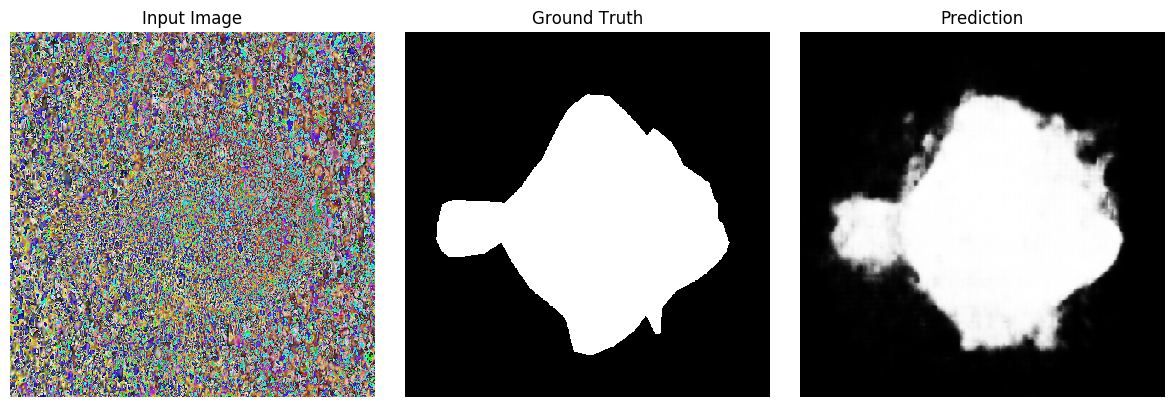

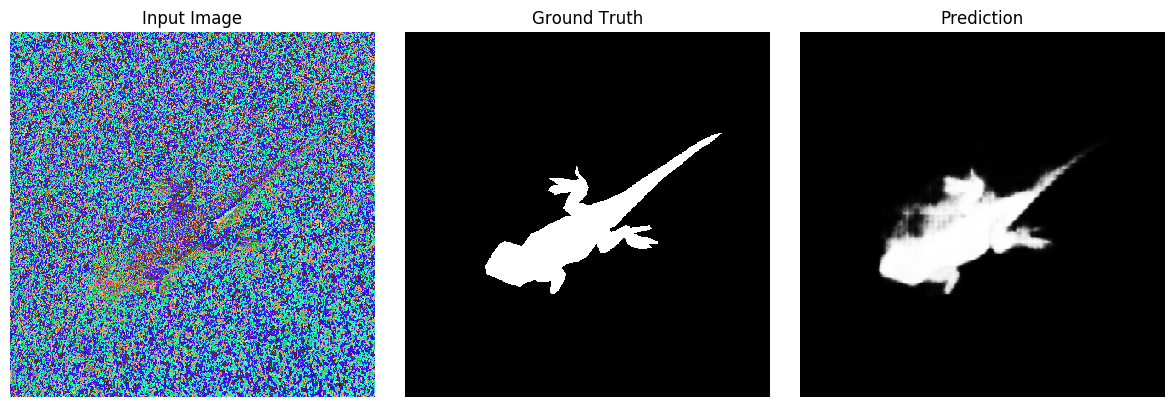

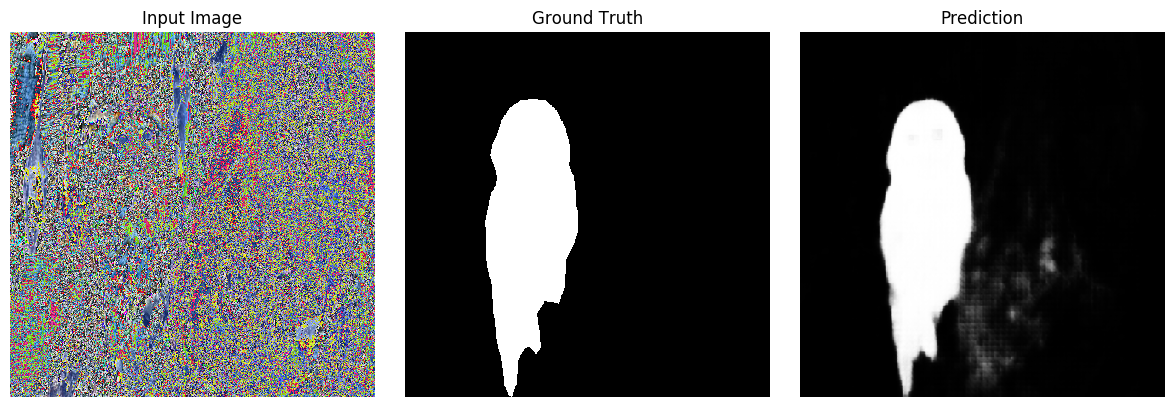

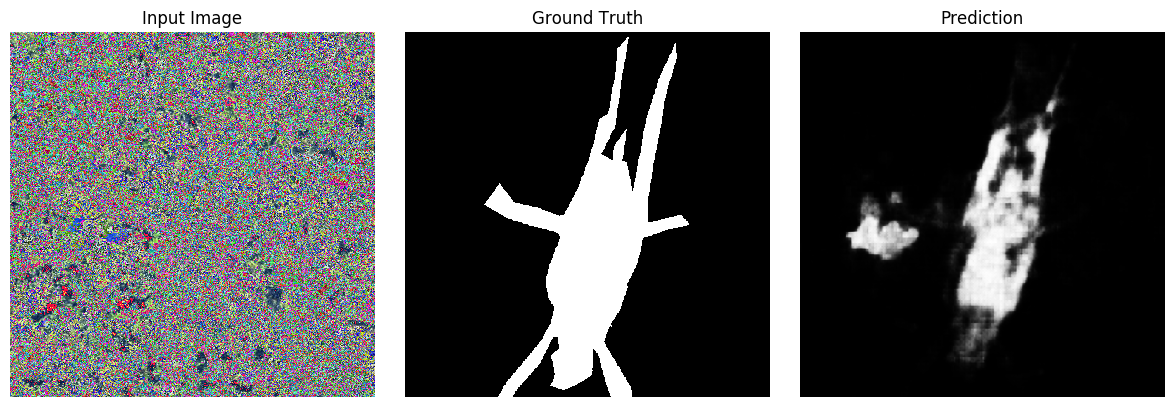

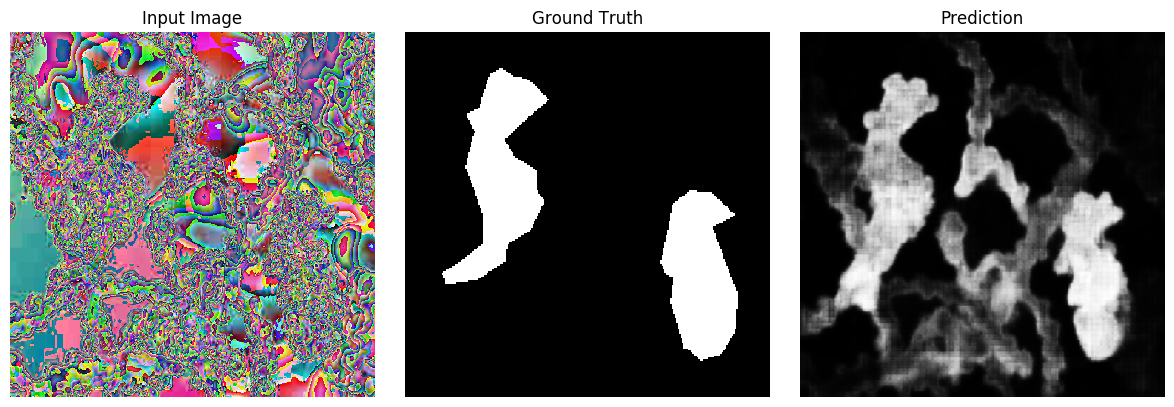

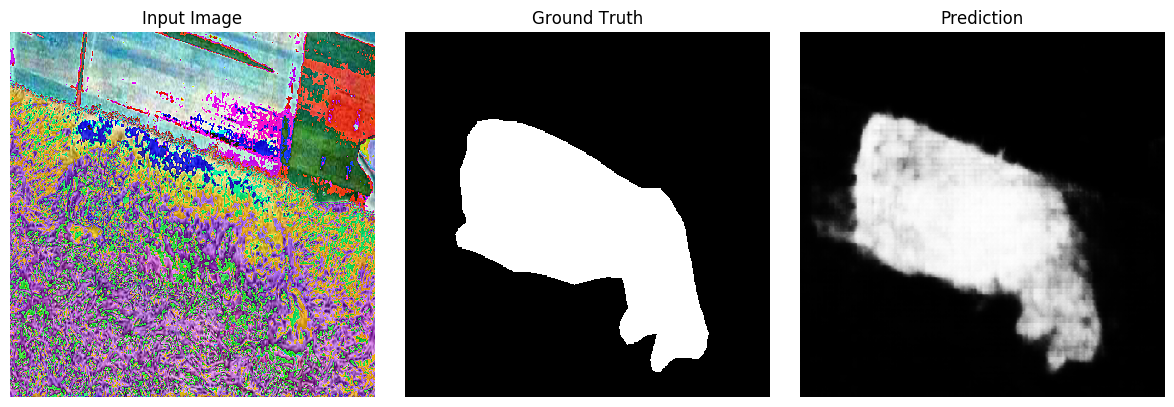

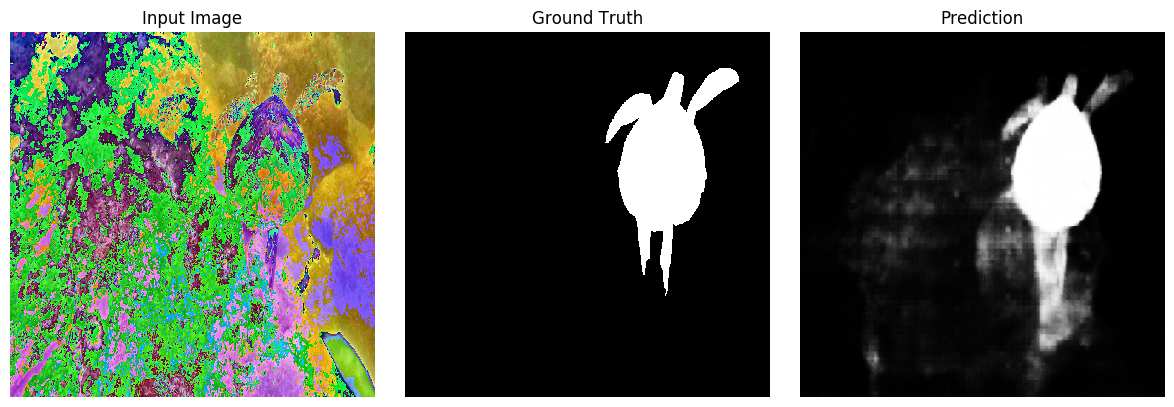

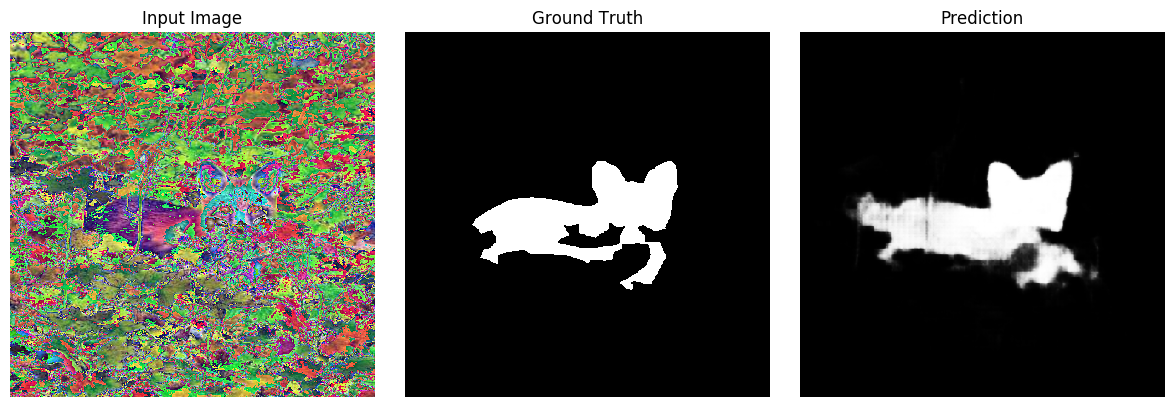

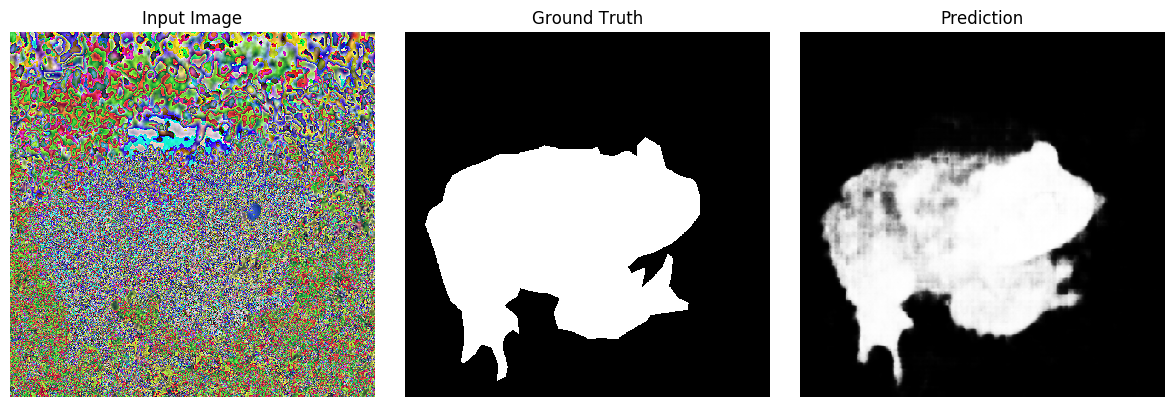

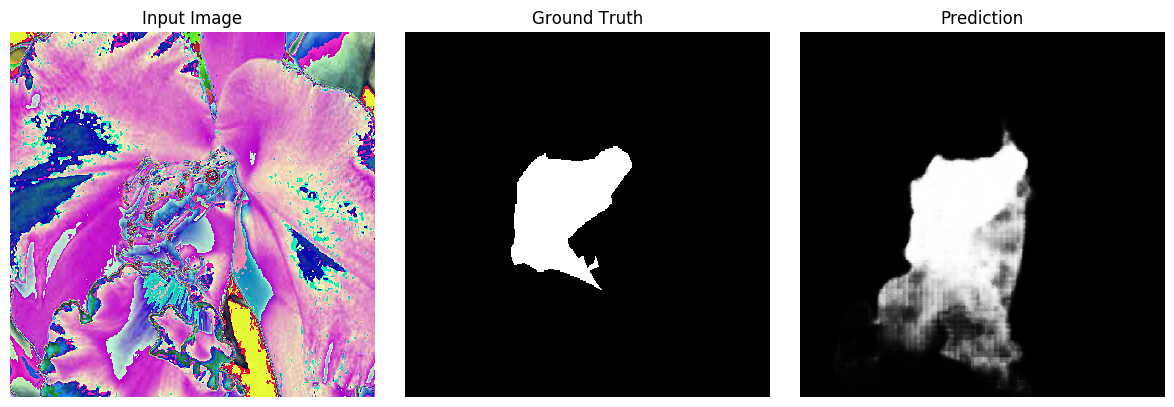

In [7]:
# inference

#pbar = tqdm(loader, leave=False, desc='val')

for i, batch in enumerate(loader):
    if i >= 10:
        break

    for k, v in batch.items():
        batch[k] = v.to(device)

    inp = batch['inp']
    gt = batch['gt']

    pred = torch.sigmoid(model.infer(inp))


    visualize_batch_sample(inp, gt, pred)